# 04_00 — Avaliação do Modelo por Voo

**Input:** artefatos de `06_models/` (isolation_forest, scaler, selected_features)  
**Input:** voos de `04_feature/` (feature-engineered)  

Este notebook aplica o modelo treinado pelo pipeline **individualmente em cada voo**,
permitindo visualizar:
- O anomaly score ao longo do tempo
- O momento real da falha vs. o primeiro alerta do modelo
- A latência de detecção por voo
- Uma tabela-resumo comparando todos os voos

## Imports e caminhos

In [1]:
import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import yaml

from aeroespacial_2.pipelines.model_training.nodes import create_windows

ROOT       = Path("../..")
MODELS_DIR = ROOT / "data/06_models"
FEAT_DIR   = ROOT / "data/04_feature"

_params = yaml.safe_load((ROOT / "conf/base/parameters.yml").read_text())["model_training"]

TARGET_COL    = "target_fault"
TIMESTAMP_COL = "timestamp"
WINDOW_SIZE   = _params["window_size"]
SKIP_SECONDS  = _params.get("skip_seconds", 0.0)
MIN_CONSECUTIVE = _params.get("min_consecutive_windows", 1)

print(f"skip_seconds carregado de parameters.yml: {SKIP_SECONDS} s")
print(f"min_consecutive_windows: {MIN_CONSECUTIVE} janelas  (≈ {MIN_CONSECUTIVE * WINDOW_SIZE / 100:.1f} s a 100 Hz)")

skip_seconds carregado de parameters.yml: 20.0 s
min_consecutive_windows: 50 janelas  (≈ 10.0 s a 100 Hz)


## Carrega artefatos do modelo

In [2]:
model           = joblib.load(MODELS_DIR / "isolation_forest.pkl")
scaler          = joblib.load(MODELS_DIR / "feature_scaler.pkl")
selected_features = json.loads((MODELS_DIR / "selected_features.json").read_text())

print(f"Features selecionadas ({len(selected_features)}):")
for i, f in enumerate(selected_features, 1):
    print(f"  {i:2d}. {f}")

Features selecionadas (20):
   1. hud_throttle_mean_50
   2. hud_throttle
   3. hud_throttle_mean_100
   4. hud_throttle_mean_200
   5. fft_peak_power_alt_global_1000
   6. fft_peak_power_alt_global_2000
   7. err_vel_z_mean_200
   8. energy_specific_slope_200
   9. err_vel_z
  10. err_vel_z_mean_100
  11. alt_gps_fix
  12. energy_specific
  13. err_vel_z_mean_50
  14. vel_z_meas
  15. vel_z_local
  16. pos_z_local
  17. vel_z_twist
  18. energy_specific_mean_50
  19. energy_specific_mean_100
  20. fft_peak_power_energy_specific_1000


## Função de avaliação por voo

In [3]:
def apply_persistence_filter(y_pred: np.ndarray, min_consecutive: int) -> np.ndarray:
    """Marca como anômala apenas janelas que fazem parte de uma sequência de
    pelo menos `min_consecutive` janelas consecutivas anômalas.

    Janelas isoladas (< min_consecutive consecutivas) são descartadas — ocorrem
    por acaso em voos normais (~contamination % do tempo) e não representam falha real.
    Uma falha real produz uma sequência sustentada de anomalias, não um único spike.
    """
    if min_consecutive <= 1:
        return y_pred.copy()
    filtered = np.zeros_like(y_pred)
    run = 0
    for i, v in enumerate(y_pred):
        if v == 1:
            run += 1
            if run >= min_consecutive:
                if run == min_consecutive:
                    filtered[i - min_consecutive + 1 : i + 1] = 1
                else:
                    filtered[i] = 1
        else:
            run = 0
    return filtered

In [4]:
def evaluate_flight(df: pd.DataFrame, flight_name: str) -> dict | None:
    """Aplica o modelo em um único voo e retorna métricas."""
    missing = [f for f in selected_features if f not in df.columns]
    if missing:
        print(f"  [SKIP] {flight_name} — features ausentes: {missing}")
        return None

    if TARGET_COL not in df.columns:
        df = df.copy()
        df[TARGET_COL] = 0

    # Remove fase de transição inicial: aeronave desce de altitude acima do cruise
    # para ~50 m nos primeiros segundos — valores de energia/altitude são similares
    # aos da falha e causam falsos alarmes. O skip é aplicado aqui na avaliação
    # e também no treino (via build_training_data).
    if SKIP_SECONDS > 0.0:
        df = df[df[TIMESTAMP_COL] >= SKIP_SECONDS].copy()

    if len(df) <= WINDOW_SIZE:
        print(f"  [SKIP] {flight_name} — muito curto após skip ({len(df)} linhas)")
        return None

    X, y = create_windows(df, WINDOW_SIZE, selected_features, TARGET_COL)
    timestamps = df[TIMESTAMP_COL].values[WINDOW_SIZE:]

    X_scaled = scaler.transform(X)
    raw_preds = model.predict(X_scaled)
    y_pred_raw = np.where(raw_preds == -1, 1, 0)
    scores     = model.decision_function(X_scaled)

    # Filtro de persistência: só alerta após MIN_CONSECUTIVE janelas consecutivas anômalas.
    # Elimina falsos alarmes isolados que surgem por acaso (~contamination % do tempo).
    y_pred = apply_persistence_filter(y_pred_raw, MIN_CONSECUTIVE)

    fault_indices = np.where(y == 1)[0]
    has_fault = len(fault_indices) > 0

    result = {
        "flight":       flight_name,
        "has_fault":    has_fault,
        "n_samples":    len(y),
        "timestamps":   timestamps,
        "y_true":       y,
        "y_pred":       y_pred,
        "y_pred_raw":   y_pred_raw,
        "scores":       scores,
        "fault_time":   None,
        "detect_time":  None,
        "latency_s":    None,
        "false_alarms": int((y_pred[y == 0] == 1).sum()),
    }

    if has_fault:
        real_idx   = fault_indices[0]
        fault_time = timestamps[real_idx]
        post_fault = np.where((y_pred == 1) & (np.arange(len(y_pred)) >= real_idx))[0]
        result["fault_time"] = float(fault_time)
        if len(post_fault) > 0:
            detect_time = timestamps[post_fault[0]]
            result["detect_time"] = float(detect_time)
            result["latency_s"]   = float(detect_time - fault_time)

    return result

## Fase de transição inicial

Os voos são gravados com a aeronave já no ar, mas frequentemente acima da altitude de cruise (~50 m).
Durante a descida inicial até o cruise, as features de energia e altitude assumem valores similares
aos da falha de motor — causando falsos alarmes no início de muitos voos.

A tabela abaixo mostra o `pos_z_local` no início e no cruise de cada voo, e até quando dura a transição.
O parâmetro `skip_seconds` (lido de `parameters.yml`) exclui este período da avaliação e do treino.

In [5]:
print(f"skip_seconds = {SKIP_SECONDS} s  (de conf/base/parameters.yml)\n")

rows_z = []
for path in sorted(FEAT_DIR.glob("*.csv")):
    df = pd.read_csv(path)
    if "pos_z_local" not in df.columns:
        continue
    t_max = df[TIMESTAMP_COL].max()
    z_inicio  = df.loc[df[TIMESTAMP_COL] < 5,  "pos_z_local"].mean()
    z_cruise  = df.loc[(df[TIMESTAMP_COL] >= 20) & (df[TIMESTAMP_COL] < t_max - 20), "pos_z_local"].mean()
    delta = abs(z_inicio - z_cruise) if not pd.isna(z_cruise) else float("nan")
    # primeiro instante em que pos_z fica dentro de ±3 m do cruise
    if not pd.isna(z_cruise) and delta > 3:
        stable_mask = (df["pos_z_local"] - z_cruise).abs() < 3.0
        idx = stable_mask.idxmax() if stable_mask.any() else None
        t_stable = float(df.loc[idx, TIMESTAMP_COL]) if idx is not None else float("nan")
    else:
        t_stable = 0.0
    rows_z.append({
        "Voo": path.stem.replace("carbonZ_", ""),
        "z_início (m)": round(z_inicio, 1),
        "z_cruise (m)": round(z_cruise, 1) if not pd.isna(z_cruise) else "—",
        "t_estável (s)": round(t_stable, 1),
        "skip cobre?": "✓" if t_stable <= SKIP_SECONDS else f"✗ ({t_stable:.1f}s)",
    })

df_z = pd.DataFrame(rows_z)
print(f"Transições que excedem skip_seconds={SKIP_SECONDS}s:")
problemas = df_z[df_z["skip cobre?"].str.startswith("✗")]
print(problemas[["Voo", "z_início (m)", "z_cruise (m)", "t_estável (s)"]].to_string(index=False) if len(problemas) else "  Nenhuma — skip cobre todas as transições.")
print()
df_z

skip_seconds = 20.0 s  (de conf/base/parameters.yml)

Transições que excedem skip_seconds=20.0s:
  Nenhuma — skip cobre todas as transições.



,Voo,z_início (m),z_cruise (m),t_estável (s),skip cobre?
0,2018-07-18-15-53-31_1_engine_failure,43.9,50.0,3.8,✓
1,2018-07-18-15-53-31_2_engine_failure,58.0,49.9,4.0,✓
2,2018-07-18-16-22-01_engine_failure_with_emr_traj,51.5,50.3,0.0,✓
3,2018-07-18-16-37-39_1_no_failure,53.3,—,0.0,✓
4,2018-07-18-16-37-39_2_engine_failure_with_emr_...,45.2,49.9,3.5,✓
5,2018-07-30-16-29-45_engine_failure_with_emr_traj,49.5,50.1,0.0,✓
6,2018-07-30-16-39-00_1_engine_failure,75.9,49.5,10.2,✓
7,2018-07-30-16-39-00_2_engine_failure,62.4,49.6,7.7,✓
8,2018-07-30-16-39-00_3_no_failure,66.4,49.1,9.1,✓
9,2018-07-30-17-10-45_engine_failure_with_emr_traj,79.7,50.0,9.8,✓


## Avalia todos os voos

In [6]:
all_results = []
csv_files   = sorted(FEAT_DIR.glob("*.csv"))

print(f"Voos encontrados: {len(csv_files)}\n")
for path in csv_files:
    df   = pd.read_csv(path)
    name = path.stem
    res  = evaluate_flight(df, name)
    if res is not None:
        all_results.append(res)
        tag = "✓ DETECTADO" if res["detect_time"] else ("✗ NÃO DETECTADO" if res["has_fault"] else "— sem falha")
        lat = f"latência={res['latency_s']:.2f}s" if res["latency_s"] is not None else ""
        print(f"  {name[:60]:<60} {tag}  {lat}")

print(f"\nTotal avaliado: {len(all_results)} voos")

Voos encontrados: 33

  carbonZ_2018-07-18-15-53-31_1_engine_failure                 ✓ DETECTADO  latência=0.14s
  carbonZ_2018-07-18-15-53-31_2_engine_failure                 ✓ DETECTADO  latência=2.60s
  carbonZ_2018-07-18-16-22-01_engine_failure_with_emr_traj     ✓ DETECTADO  latência=0.41s
  carbonZ_2018-07-18-16-37-39_1_no_failure                     — sem falha  
  carbonZ_2018-07-18-16-37-39_2_engine_failure_with_emr_traj   ✓ DETECTADO  latência=0.24s
  carbonZ_2018-07-30-16-29-45_engine_failure_with_emr_traj     ✓ DETECTADO  latência=2.56s
  carbonZ_2018-07-30-16-39-00_1_engine_failure                 ✓ DETECTADO  latência=2.32s
  carbonZ_2018-07-30-16-39-00_2_engine_failure                 ✓ DETECTADO  latência=7.84s
  carbonZ_2018-07-30-16-39-00_3_no_failure                     — sem falha  
  carbonZ_2018-07-30-17-10-45_engine_failure_with_emr_traj     ✓ DETECTADO  latência=2.28s
  carbonZ_2018-07-30-17-20-01_engine_failure_with_emr_traj     ✓ DETECTADO  latência=1.12s
  car

## Tabela-resumo

In [7]:
rows = []
for r in all_results:
    rows.append({
        "Voo":           r["flight"].replace("carbonZ_", ""),
        "Falha real":    "Sim" if r["has_fault"] else "Não",
        "Detectado":     "Sim" if r["detect_time"] else ("Não" if r["has_fault"] else "—"),
        "t_falha (s)":   f"{r['fault_time']:.1f}" if r["fault_time"] else "—",
        "t_alerta (s)":  f"{r['detect_time']:.1f}" if r["detect_time"] else "—",
        "Latência (s)":  f"{r['latency_s']:.2f}" if r["latency_s"] is not None else "—",
        "Falsos alarmes": r["false_alarms"],
    })

summary = pd.DataFrame(rows)

detected     = summary[summary["Detectado"] == "Sim"]
missed       = summary[(summary["Falha real"] == "Sim") & (summary["Detectado"] == "Não")]
no_fault     = summary[summary["Falha real"] == "Não"]

print(f"Falhas detectadas:     {len(detected)}")
print(f"Falhas não detectadas: {len(missed)}")
print(f"Voos normais:          {len(no_fault)}")
if len(detected) > 0:
    lats = [r["latency_s"] for r in all_results if r["latency_s"] is not None]
    print(f"Latência média:        {np.mean(lats):.2f}s")
    print(f"Latência mediana:      {np.median(lats):.2f}s")

summary

Falhas detectadas:     23
Falhas não detectadas: 0
Voos normais:          10
Latência média:        1.93s
Latência mediana:      1.72s


,Voo,Falha real,Detectado,t_falha (s),t_alerta (s),Latência (s),Falsos alarmes
0,2018-07-18-15-53-31_1_engine_failure,Sim,Sim,115.3,115.4,0.14,0
1,2018-07-18-15-53-31_2_engine_failure,Sim,Sim,72.4,75.0,2.60,0
2,2018-07-18-16-22-01_engine_failure_with_emr_traj,Sim,Sim,115.6,116.1,0.41,1029
3,2018-07-18-16-37-39_1_no_failure,Não,—,—,—,—,0
4,2018-07-18-16-37-39_2_engine_failure_with_emr_...,Sim,Sim,113.1,113.3,0.24,0
5,2018-07-30-16-29-45_engine_failure_with_emr_traj,Sim,Sim,122.2,124.7,2.56,0
6,2018-07-30-16-39-00_1_engine_failure,Sim,Sim,115.8,118.1,2.32,0
7,2018-07-30-16-39-00_2_engine_failure,Sim,Sim,90.7,98.5,7.84,286
8,2018-07-30-16-39-00_3_no_failure,Não,—,—,—,—,368
9,2018-07-30-17-10-45_engine_failure_with_emr_traj,Sim,Sim,116.2,118.5,2.28,0


## Visualização por voo

Cada gráfico mostra:
- **Painel superior:** falha real (vermelho) vs. alertas do modelo (azul)
- **Painel inferior:** anomaly score — quanto mais negativo, mais anômalo

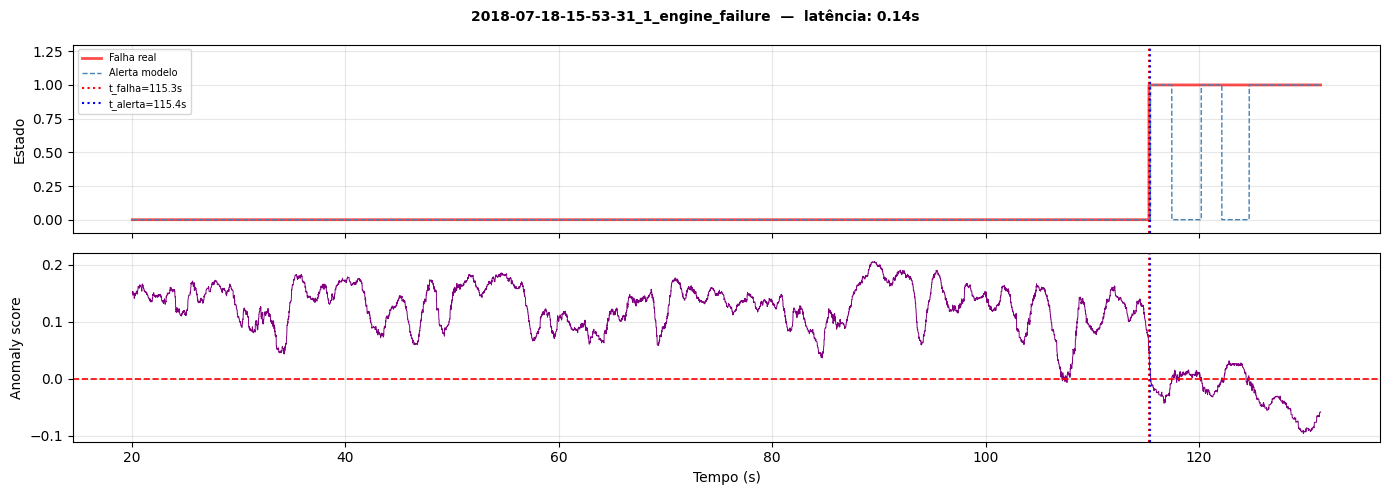

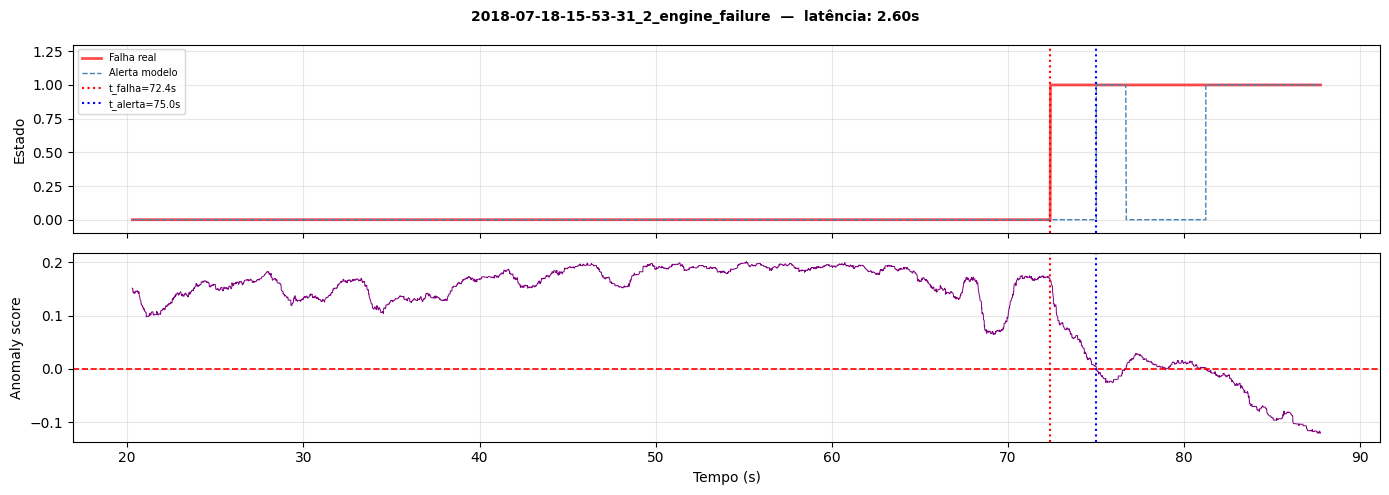

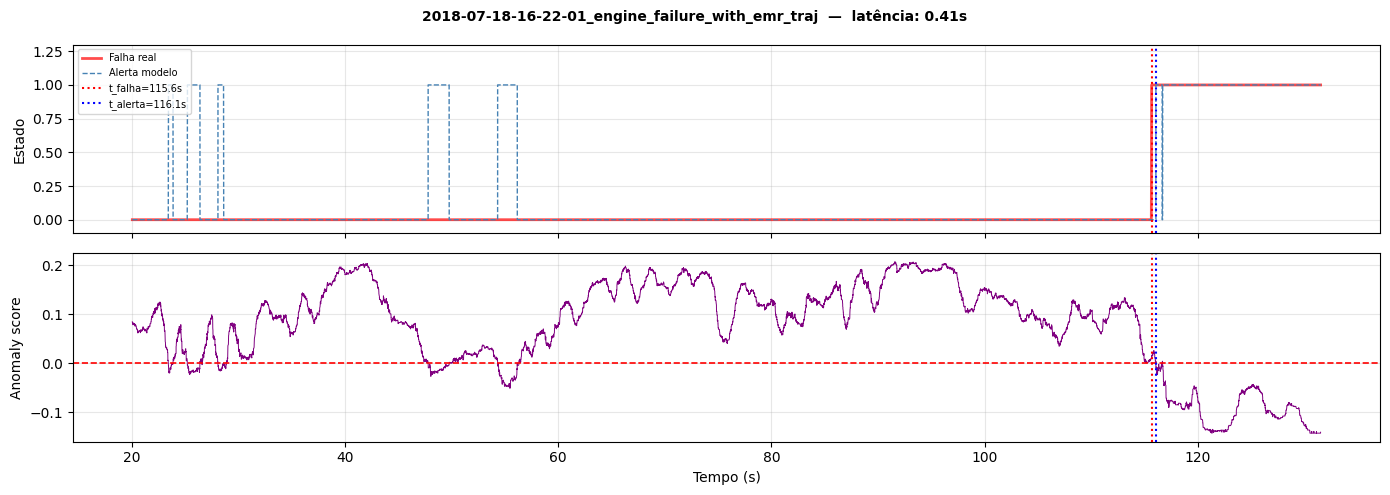

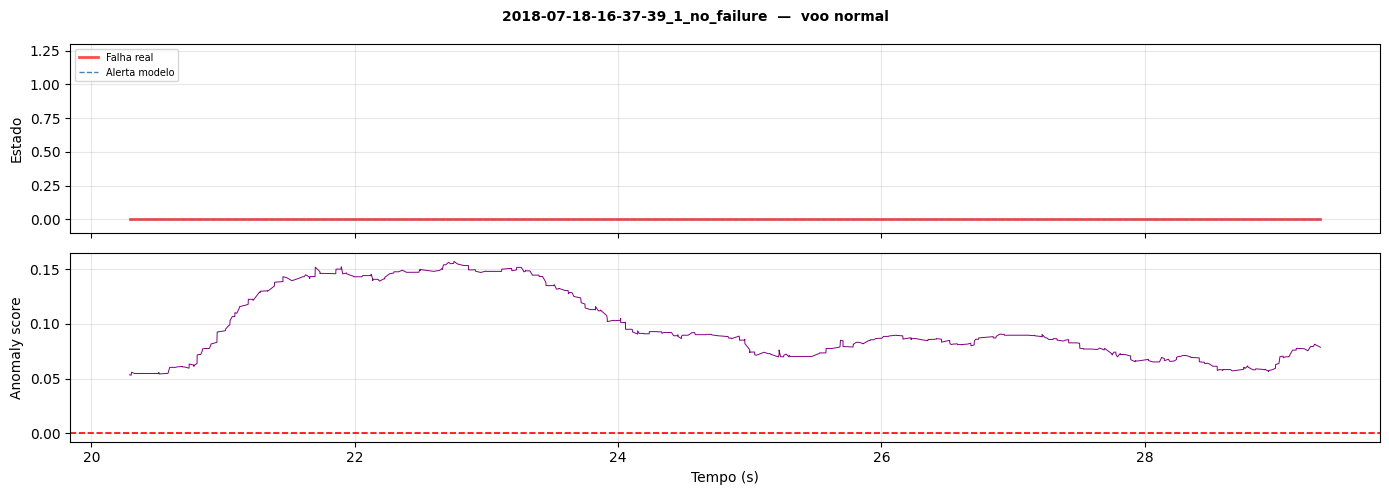

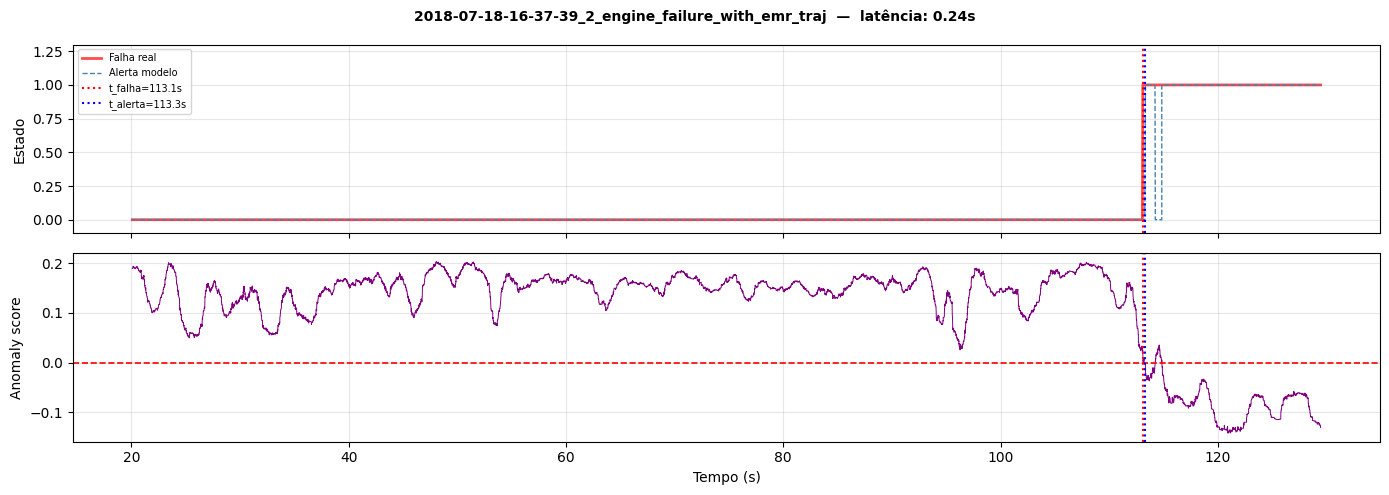

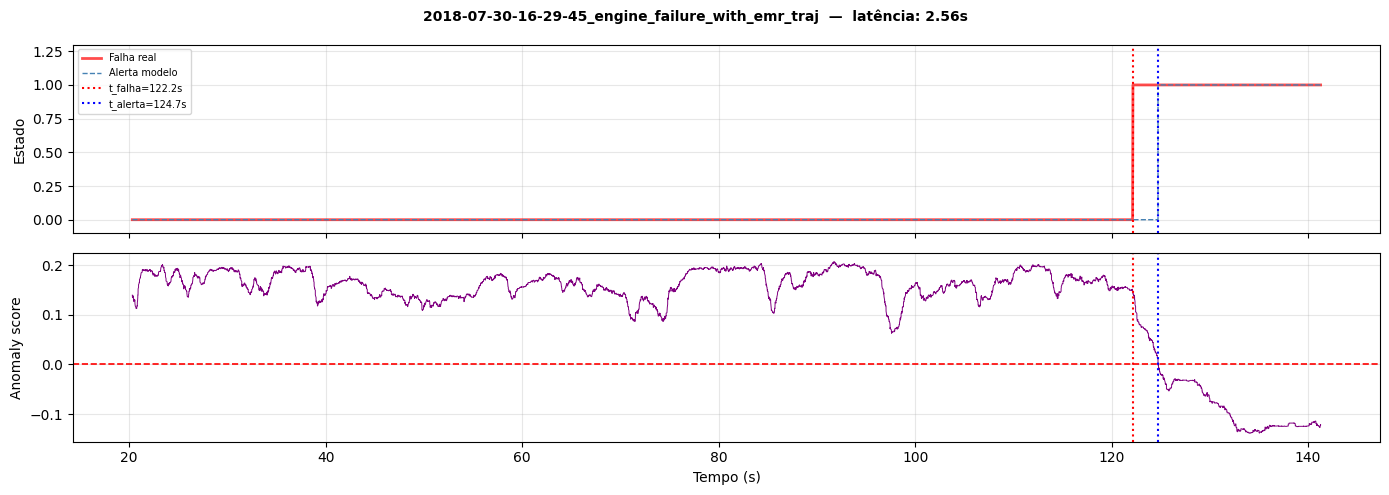

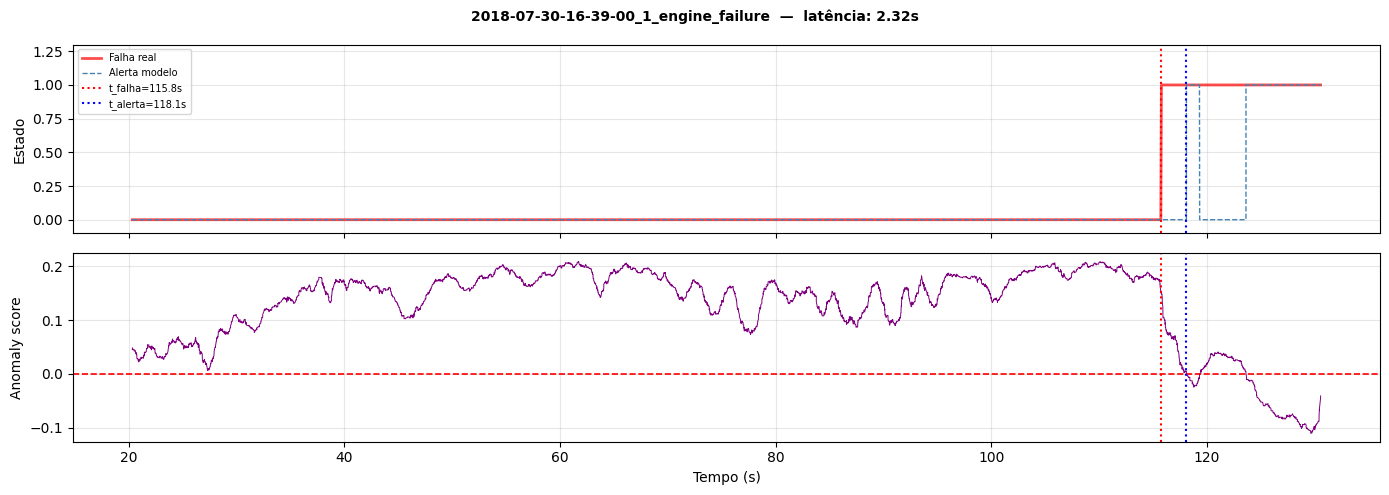

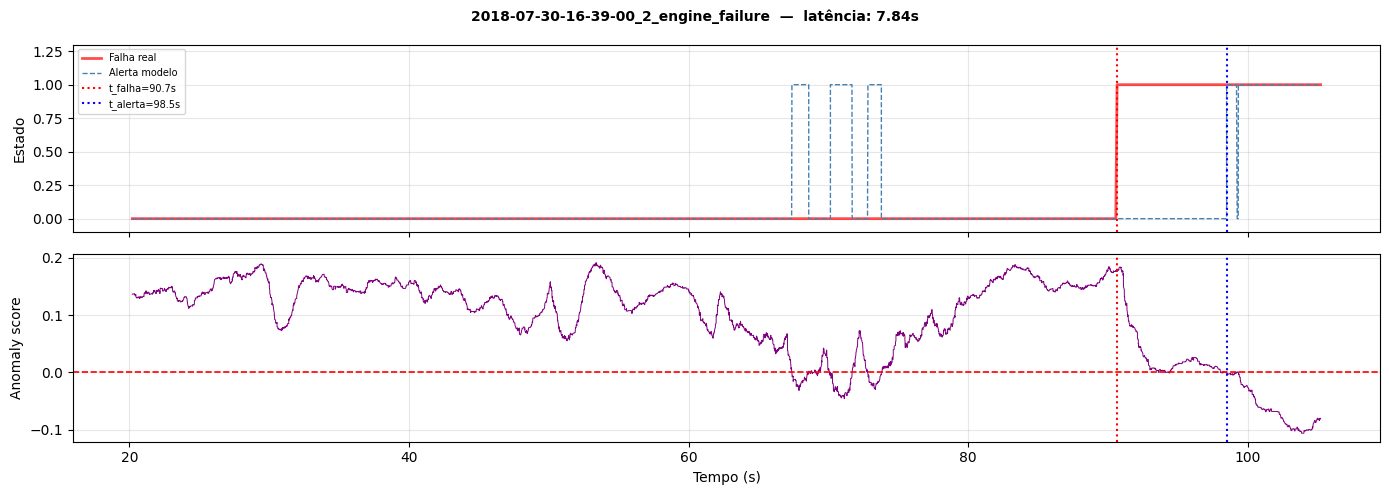

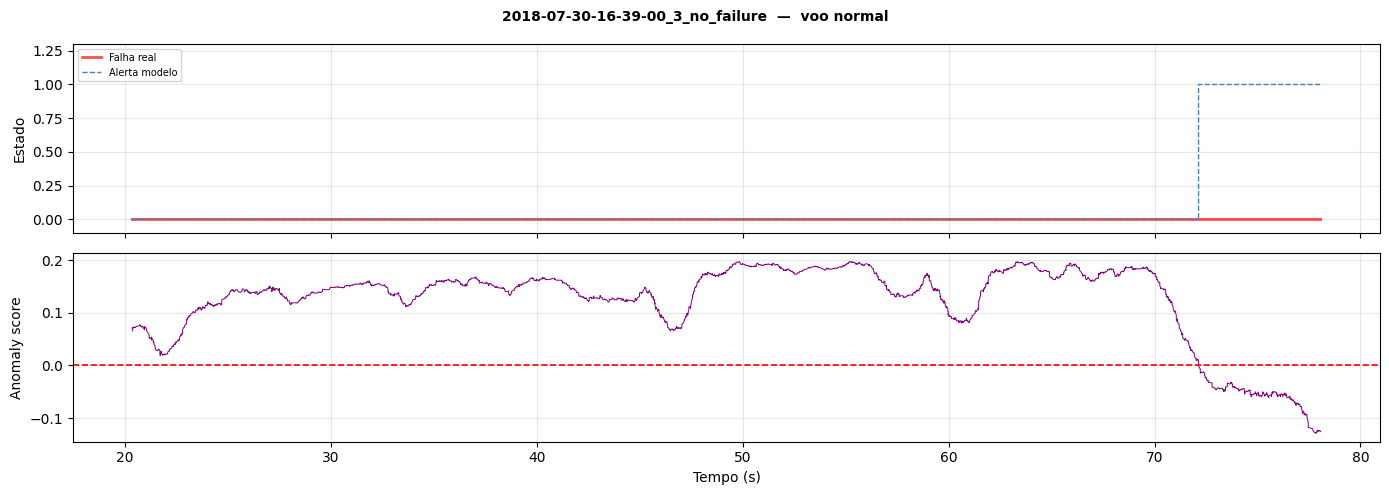

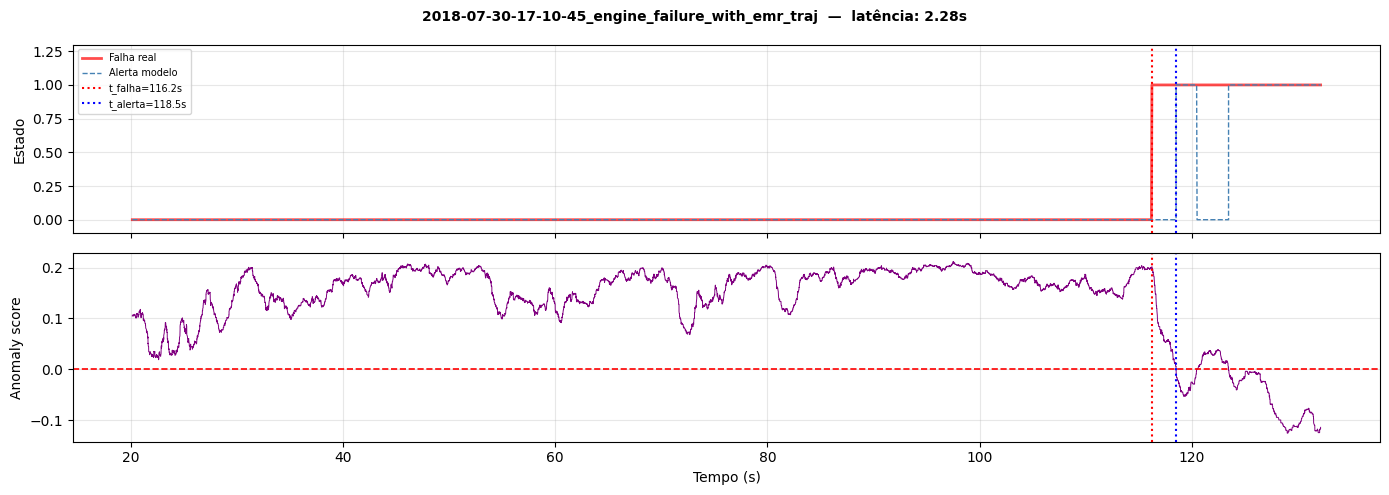

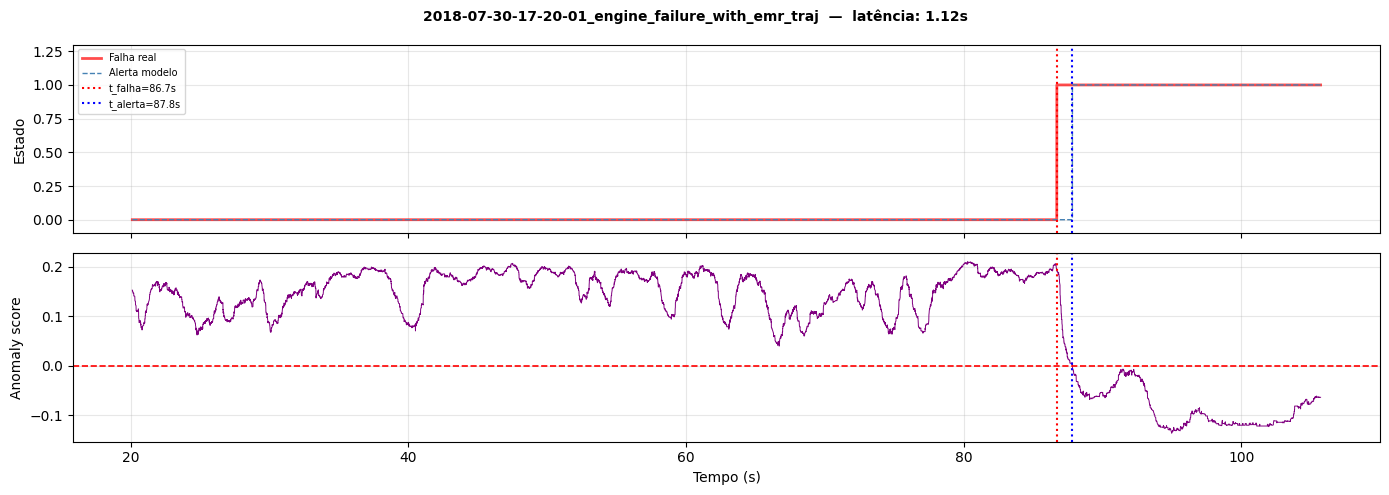

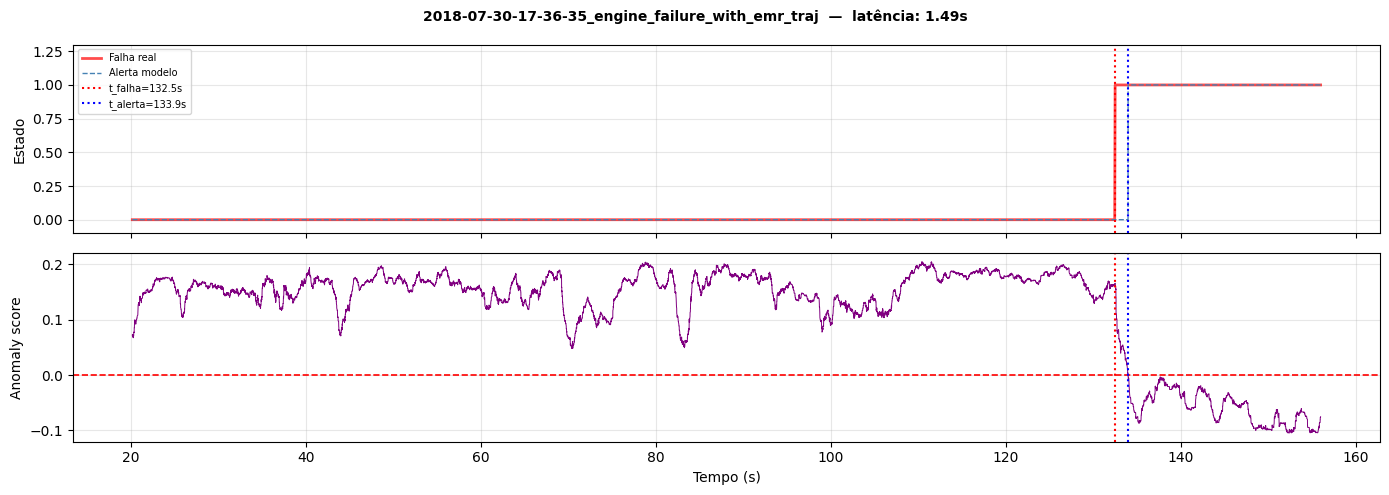

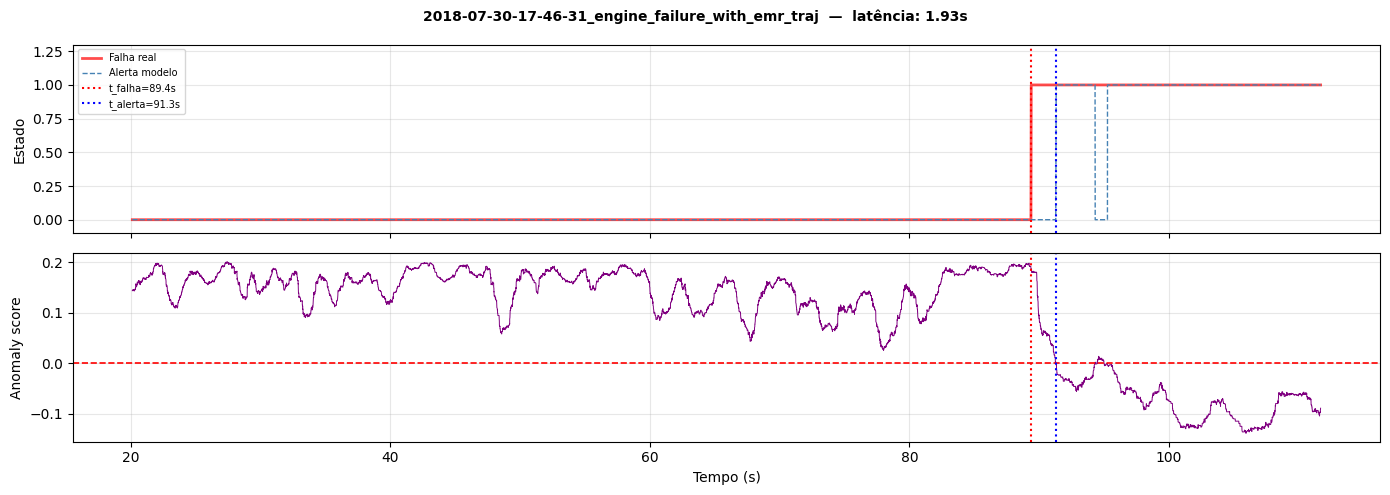

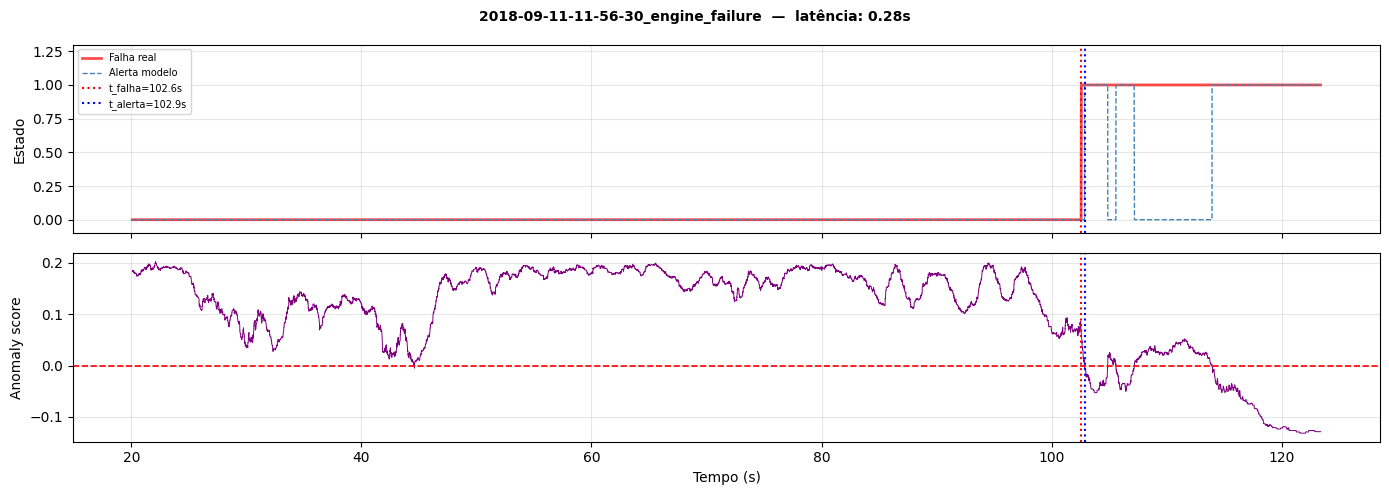

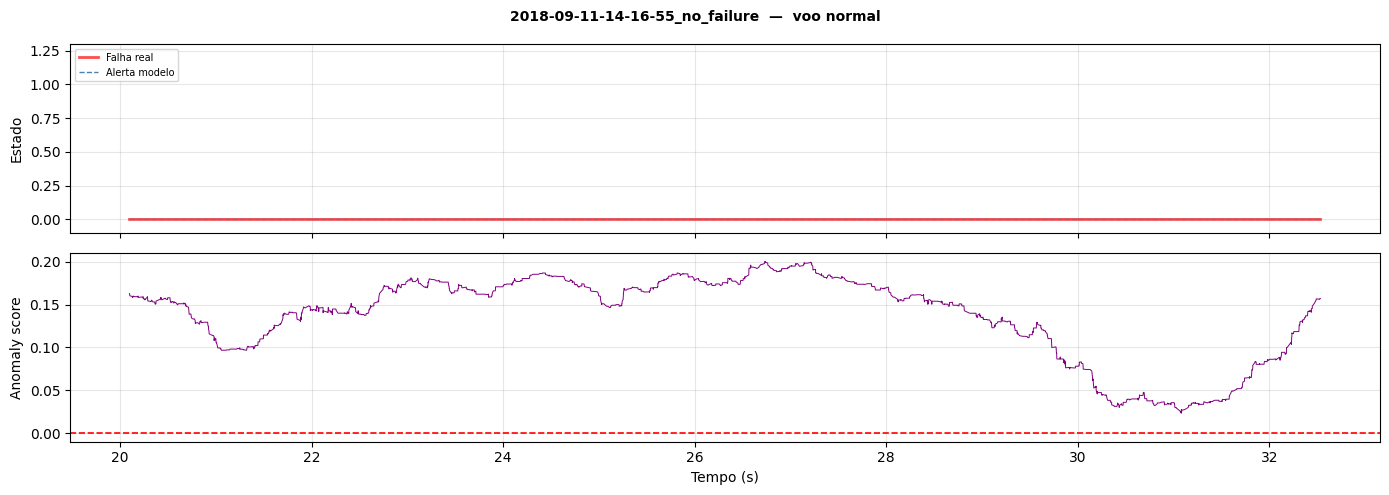

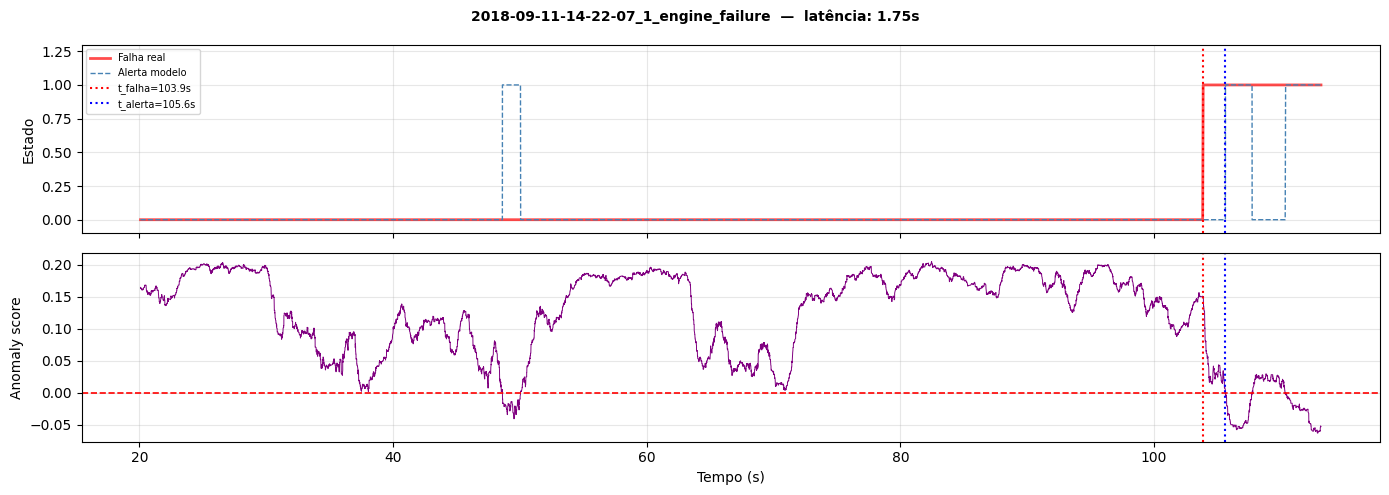

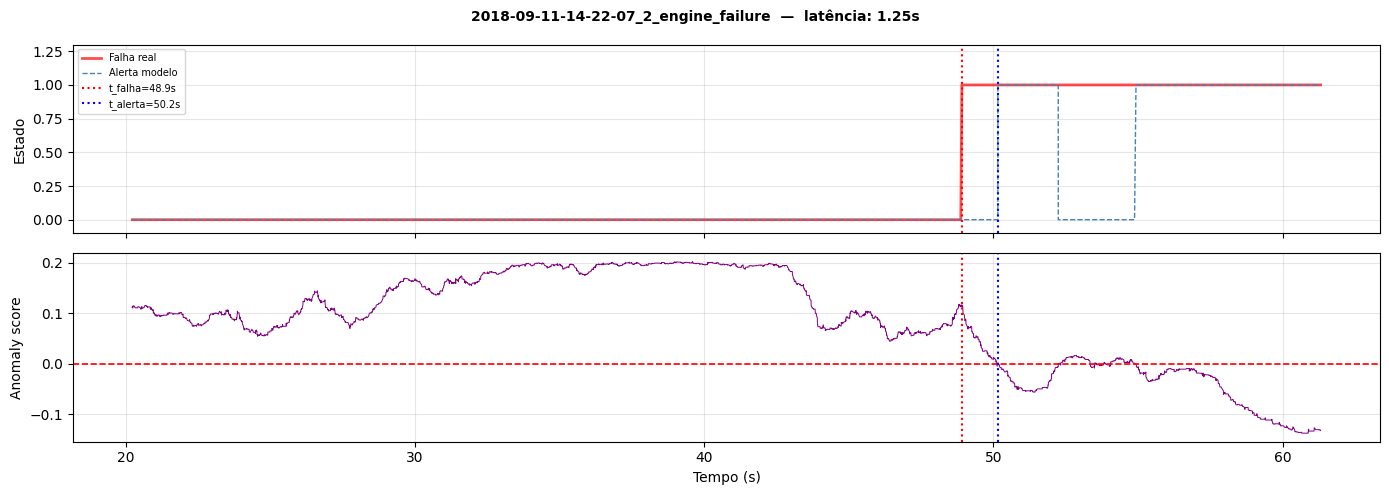

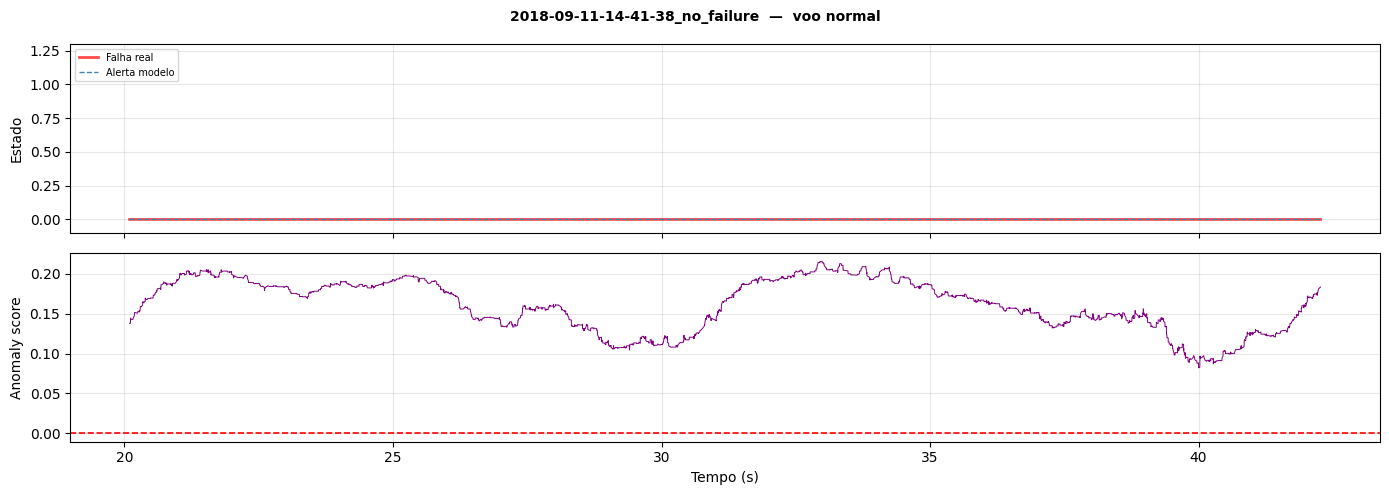

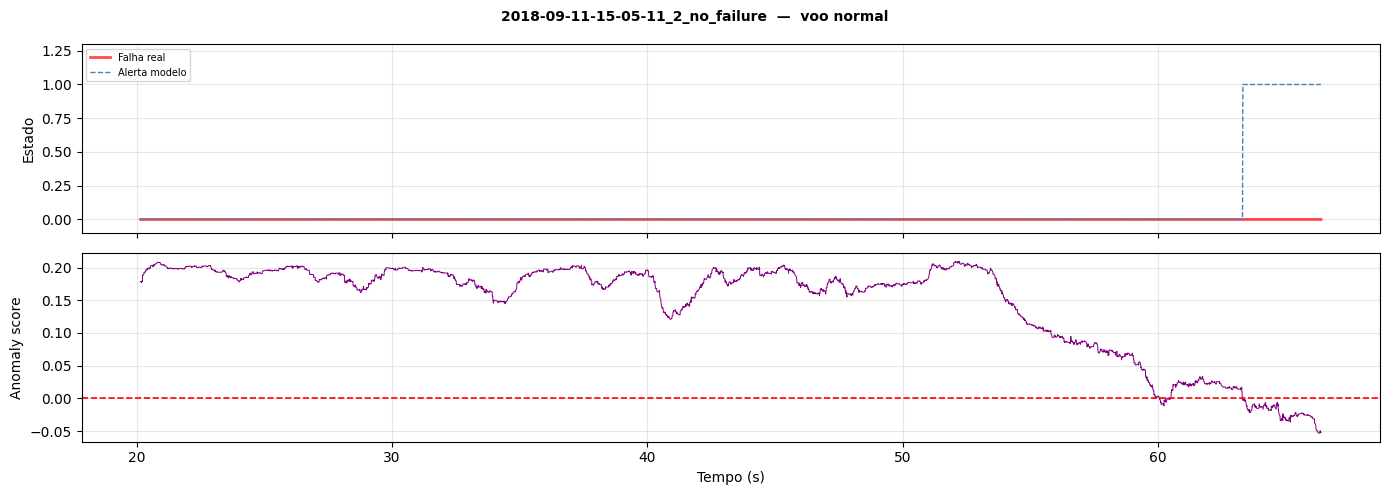

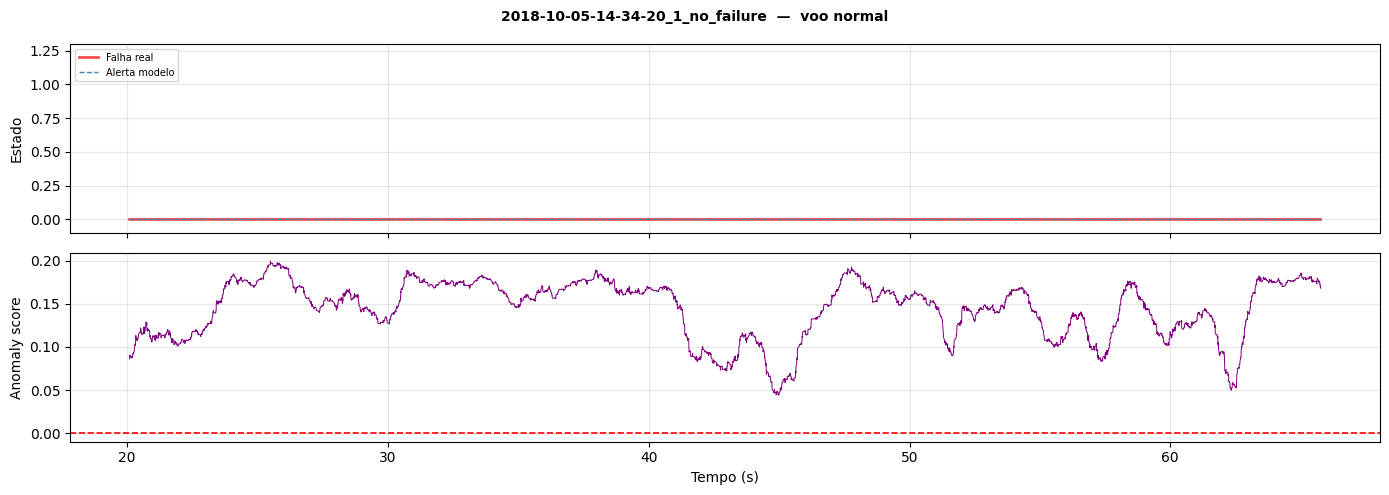

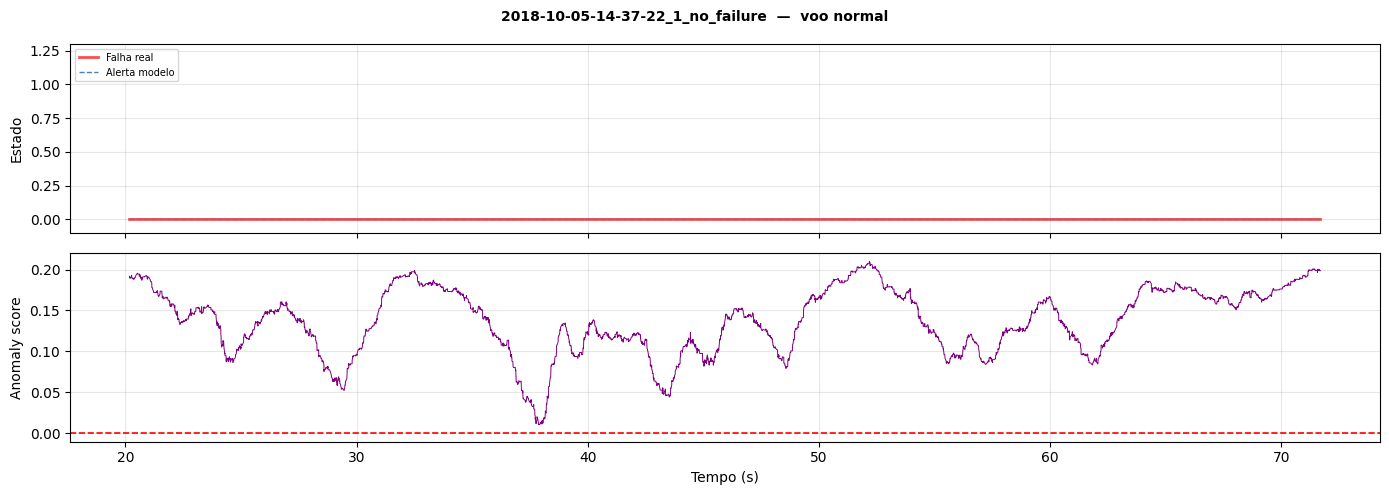

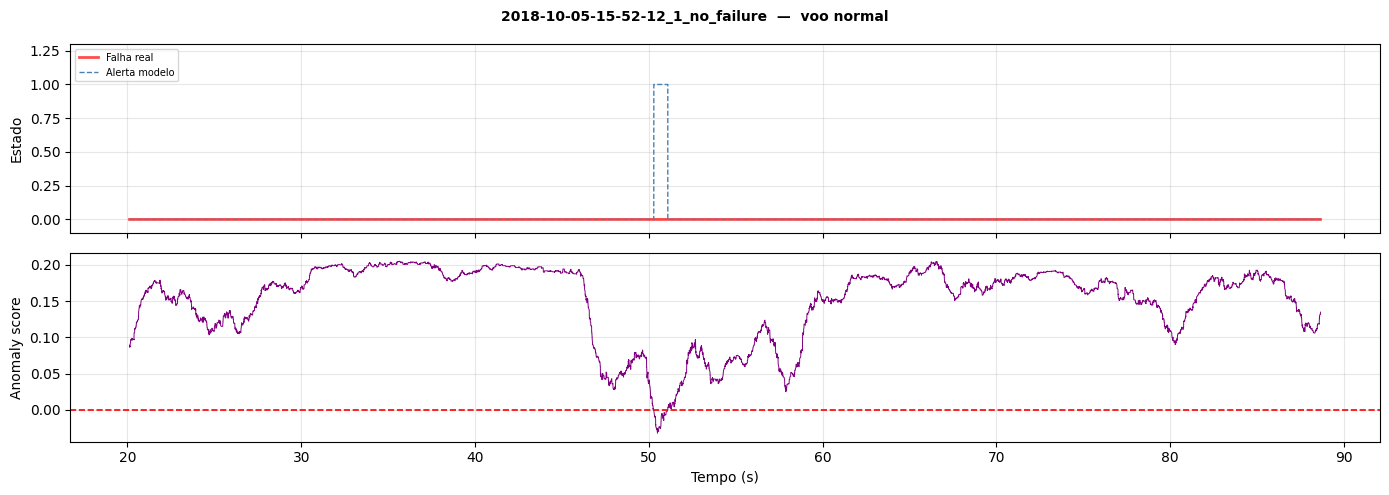

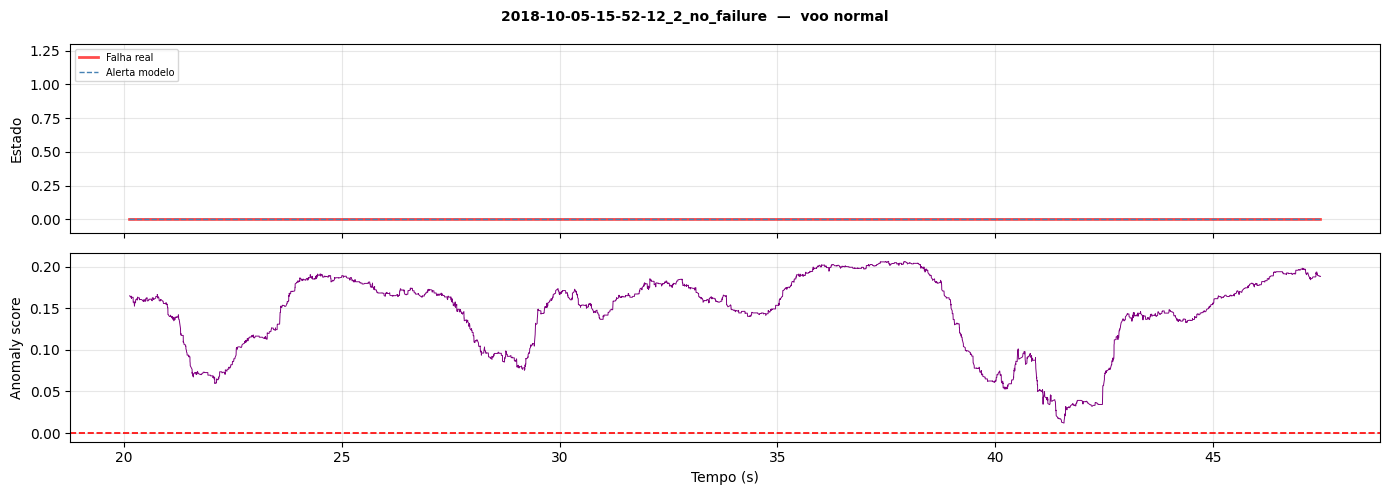

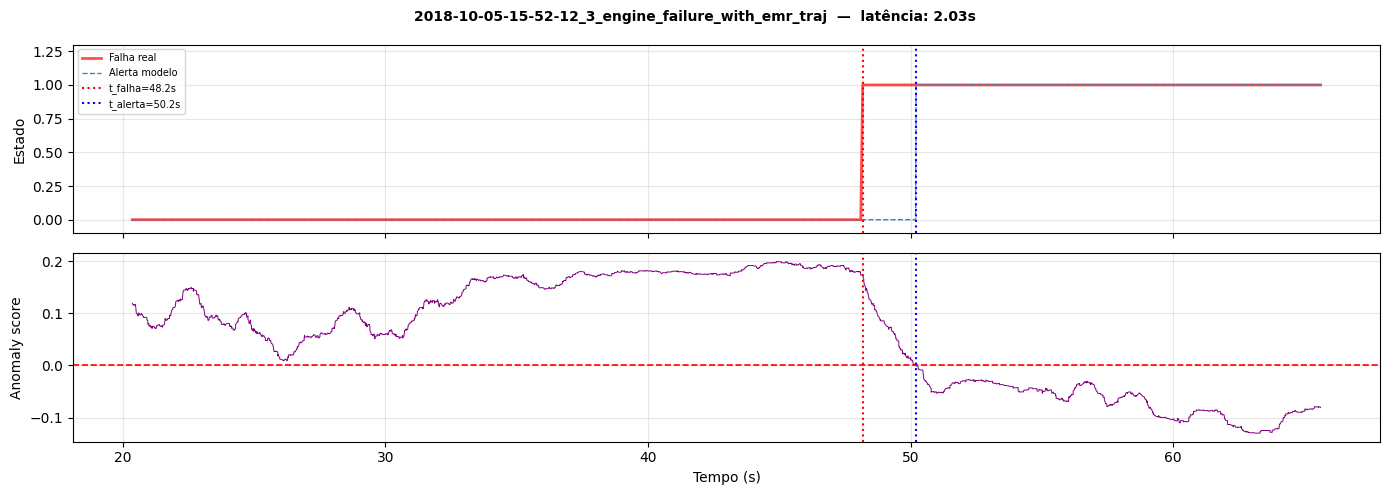

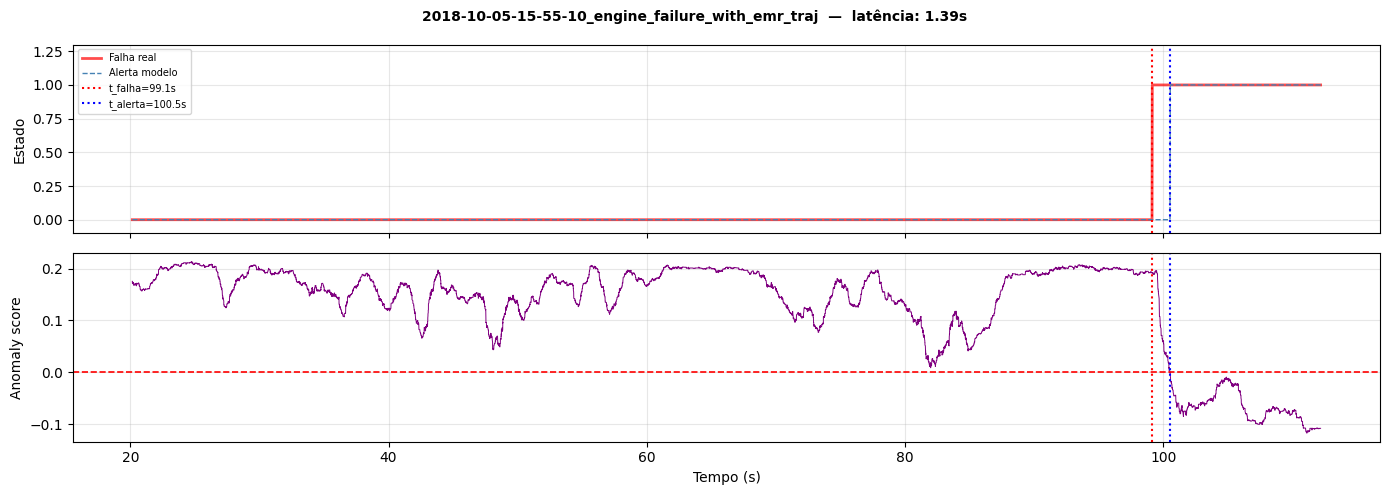

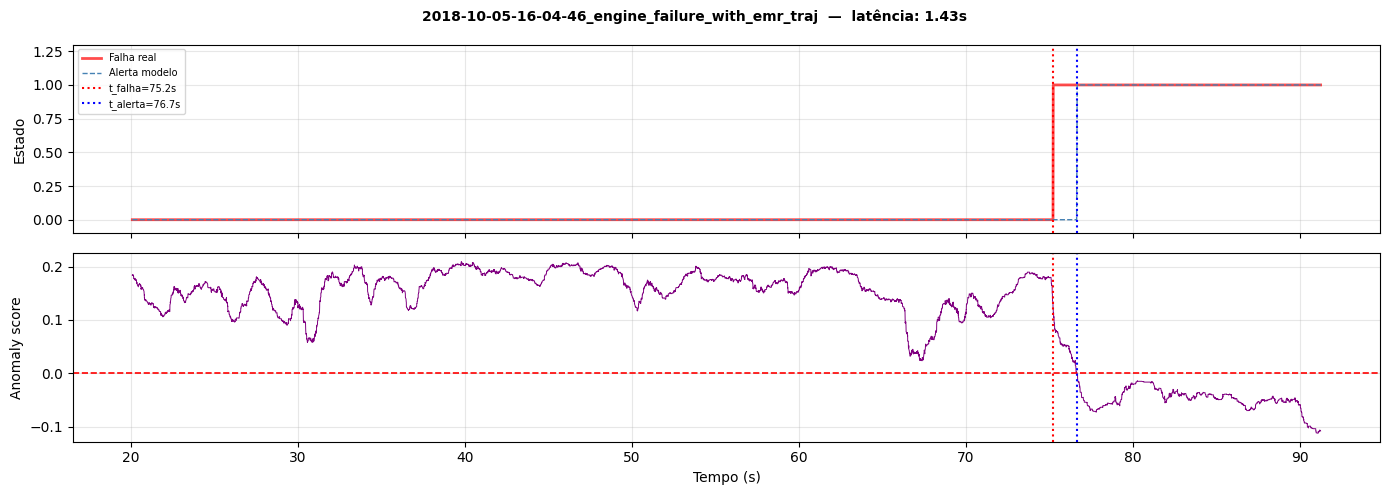

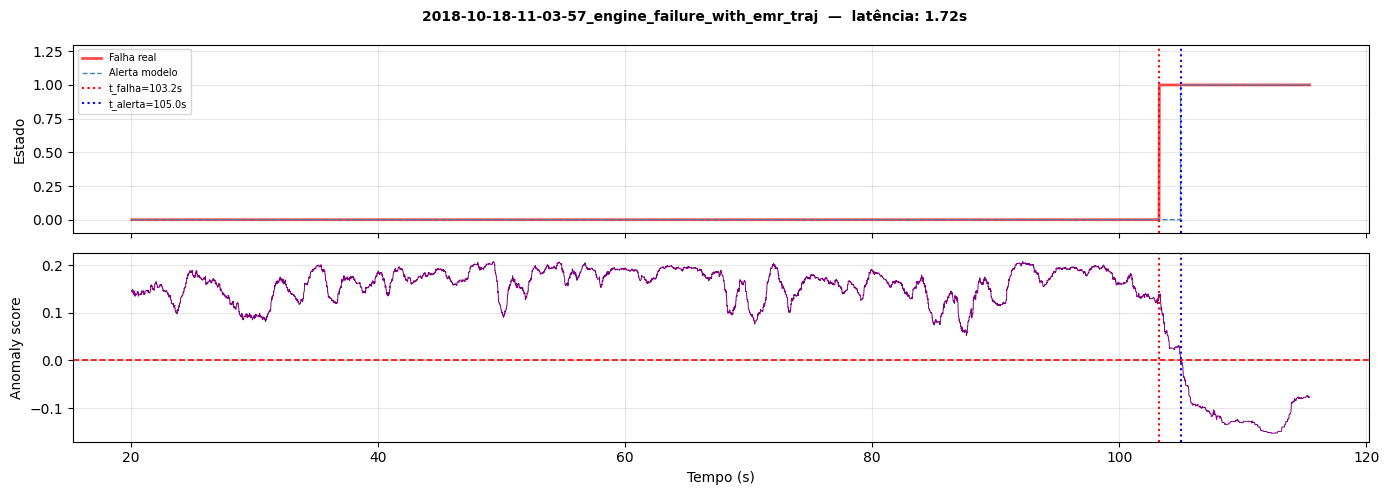

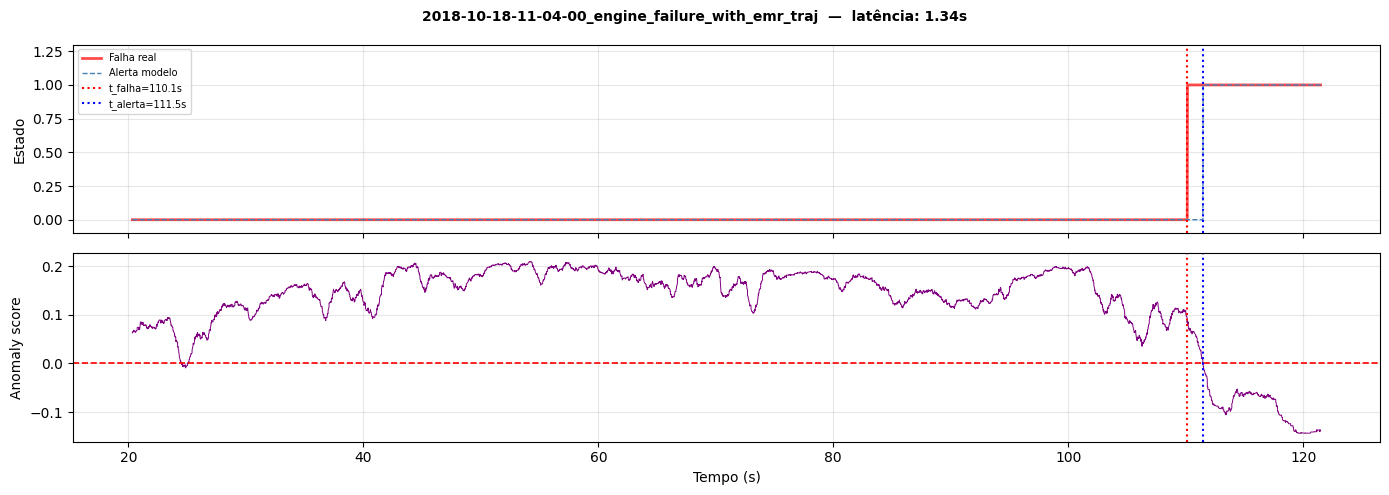

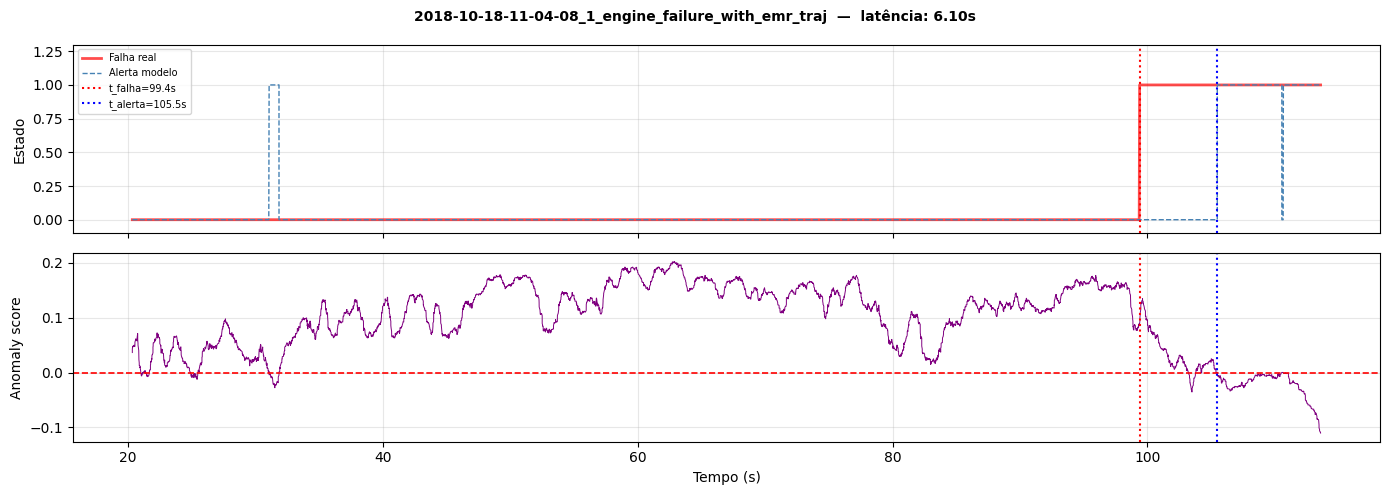

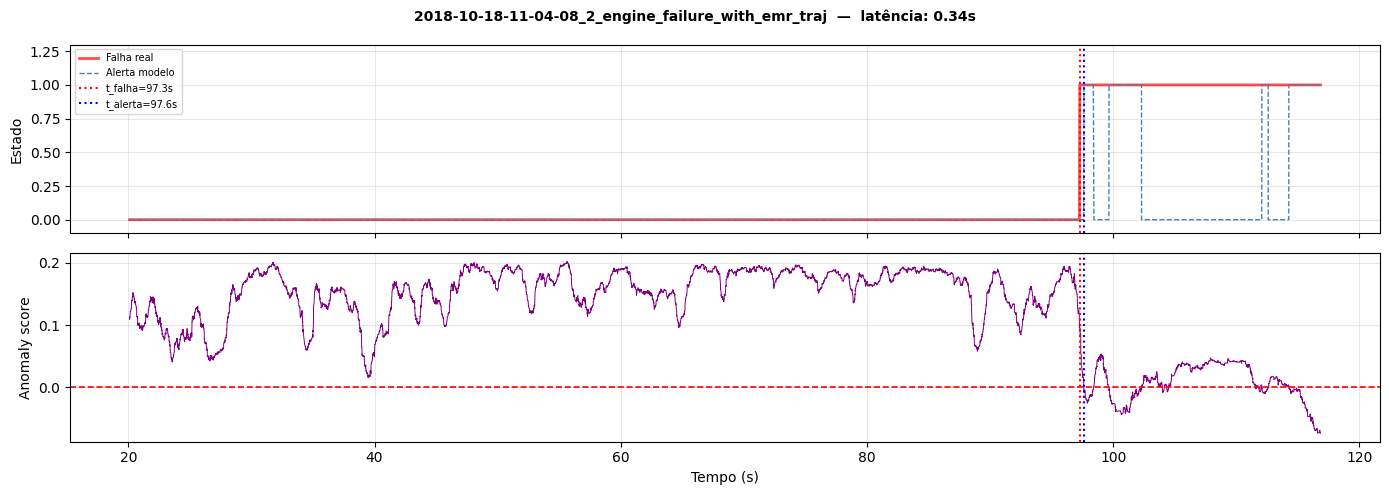

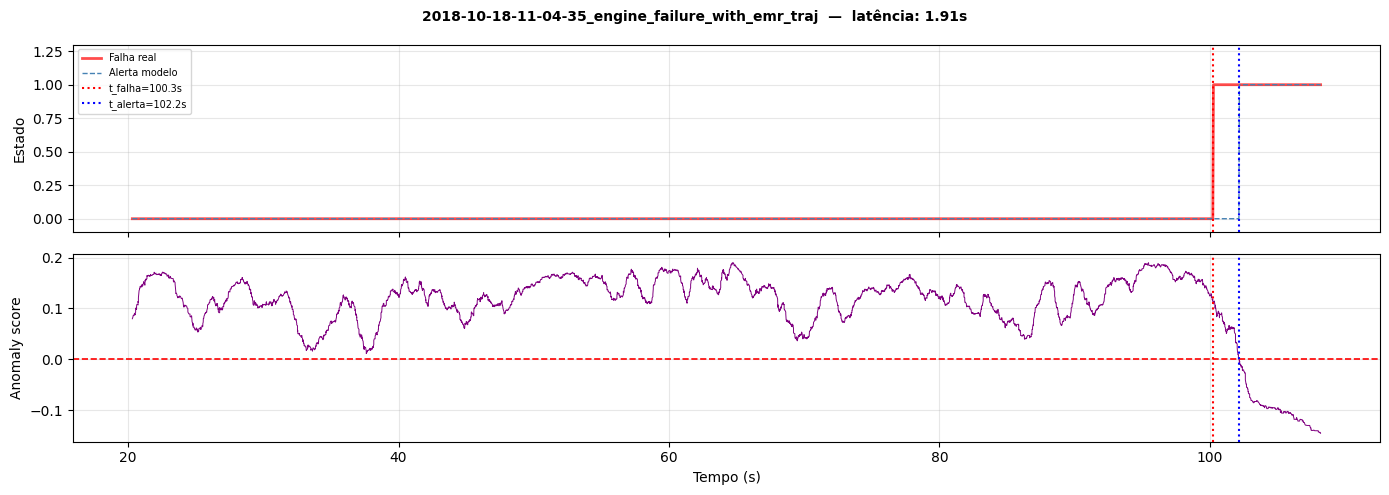

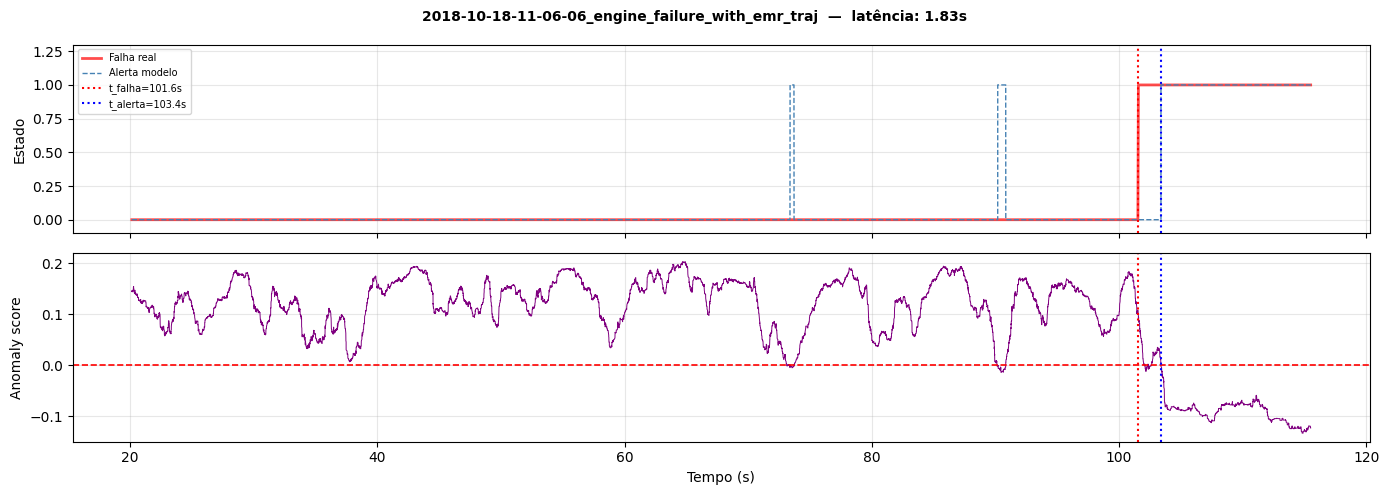

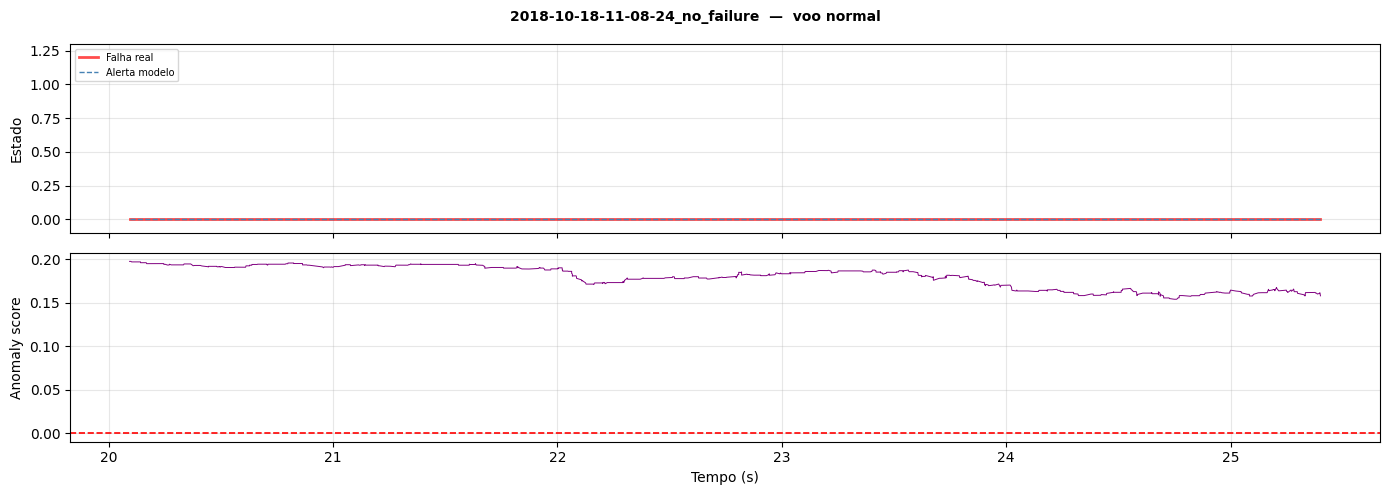

In [8]:
def plot_flight(r: dict, ax_top, ax_bot):
    ts, y_true, y_pred, scores = r["timestamps"], r["y_true"], r["y_pred"], r["scores"]

    ax_top.plot(ts, y_true,  color="red",    alpha=0.7, lw=2,   label="Falha real")
    ax_top.plot(ts, y_pred,  color="steelblue", lw=1, ls="--", label="Alerta modelo")
    if r["fault_time"]:
        ax_top.axvline(r["fault_time"],  color="red",   lw=1.5, ls=":", label=f"t_falha={r['fault_time']:.1f}s")
    if r["detect_time"]:
        ax_top.axvline(r["detect_time"], color="blue",  lw=1.5, ls=":", label=f"t_alerta={r['detect_time']:.1f}s")
    ax_top.set_ylabel("Estado")
    ax_top.set_ylim(-0.1, 1.3)
    ax_top.legend(fontsize=7, loc="upper left")
    ax_top.grid(True, alpha=0.3)

    ax_bot.plot(ts, scores, color="purple", lw=0.7)
    ax_bot.axhline(0, color="red", lw=1.2, ls="--", label="Limiar")
    if r["fault_time"]:
        ax_bot.axvline(r["fault_time"],  color="red",  lw=1.5, ls=":")
    if r["detect_time"]:
        ax_bot.axvline(r["detect_time"], color="blue", lw=1.5, ls=":")
    ax_bot.set_ylabel("Anomaly score")
    ax_bot.set_xlabel("Tempo (s)")
    ax_bot.grid(True, alpha=0.3)


for r in all_results:
    fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
    label = r["flight"].replace("carbonZ_", "")
    if r["latency_s"] is not None:
        titulo = f"{label}  —  latência: {r['latency_s']:.2f}s"
    elif r["has_fault"] and r["detect_time"] is None:
        titulo = f"{label}  —  NÃO DETECTADO"
    else:
        titulo = f"{label}  —  voo normal"
    fig.suptitle(titulo, fontsize=10, fontweight="bold")
    plot_flight(r, ax_top, ax_bot)
    plt.tight_layout()
    plt.show()

## Distribuição de latências (voos com falha detectada)

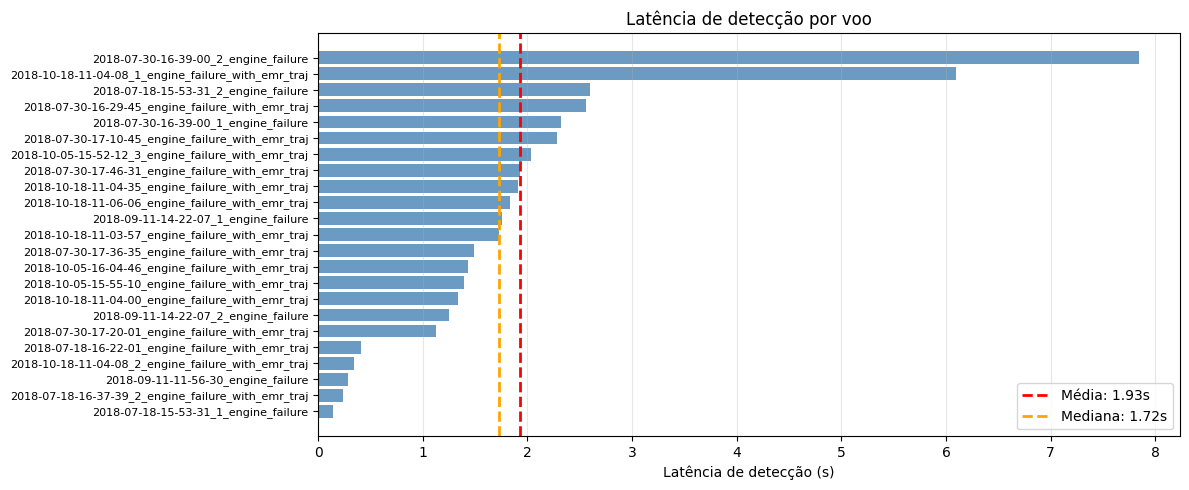

In [9]:
latencias = [(r["flight"].replace("carbonZ_", ""), r["latency_s"])
             for r in all_results if r["latency_s"] is not None]

if latencias:
    nomes, vals = zip(*sorted(latencias, key=lambda x: x[1]))
    fig, ax = plt.subplots(figsize=(12, 5))
    bars = ax.barh(range(len(vals)), vals, color="steelblue", alpha=0.8)
    ax.axvline(np.mean(vals),   color="red",    lw=2, ls="--", label=f"Média: {np.mean(vals):.2f}s")
    ax.axvline(np.median(vals), color="orange", lw=2, ls="--", label=f"Mediana: {np.median(vals):.2f}s")
    ax.set_yticks(range(len(nomes)))
    ax.set_yticklabels([n[:55] for n in nomes], fontsize=8)
    ax.set_xlabel("Latência de detecção (s)")
    ax.set_title("Latência de detecção por voo")
    ax.legend()
    ax.grid(True, alpha=0.3, axis="x")
    plt.tight_layout()
    plt.show()
else:
    print("Nenhuma falha detectada — verifique o parâmetro contamination.")

## Matriz de Confusão — Voos com falha real

Considera apenas os voos que **tiveram falha real** e classifica cada um em uma de três categorias,
com base no **primeiro alerta** emitido pelo modelo:

| Categoria | Descrição |
|-----------|-----------|
| **Durante a falha (TP)** | Primeiro alerta ocorre dentro do período em que `y_true == 1` |
| **Antes da falha (FP antecipado)** | Primeiro alerta ocorre **antes** do início da falha real |
| **Sem alerta (FN)** | Modelo não emitiu nenhum alerta durante o voo |

Voo                                                           Classificação
--------------------------------------------------------------------------------
  2018-07-18-15-53-31_1_engine_failure                        Durante a falha (TP)
  2018-07-18-15-53-31_2_engine_failure                        Durante a falha (TP)
  2018-07-18-16-22-01_engine_failure_with_emr_traj            Antes da falha (FP)
  2018-07-18-16-37-39_2_engine_failure_with_emr_traj          Durante a falha (TP)
  2018-07-30-16-29-45_engine_failure_with_emr_traj            Durante a falha (TP)
  2018-07-30-16-39-00_1_engine_failure                        Durante a falha (TP)
  2018-07-30-16-39-00_2_engine_failure                        Antes da falha (FP)
  2018-07-30-17-10-45_engine_failure_with_emr_traj            Durante a falha (TP)
  2018-07-30-17-20-01_engine_failure_with_emr_traj            Durante a falha (TP)
  2018-07-30-17-36-35_engine_failure_with_emr_traj            Durante a falha (TP)
  2018-07-30-17

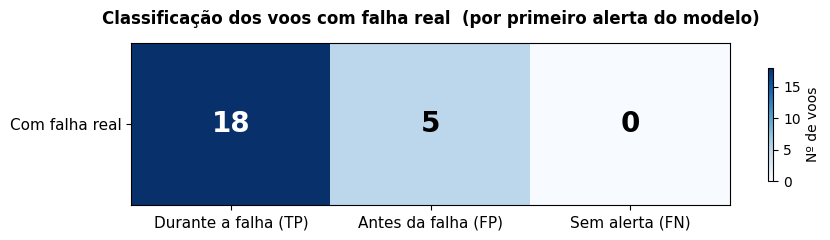

In [10]:
def classify_fault_flight(r: dict) -> str:
    """Classifica um voo com falha real com base no primeiro alerta do modelo."""
    real_idx = int(np.where(r["y_true"] == 1)[0][0])
    alert_indices = np.where(r["y_pred"] == 1)[0]

    if len(alert_indices) == 0:
        return "Sem alerta (FN)"
    first_alert = int(alert_indices[0])
    if first_alert < real_idx:
        return "Antes da falha (FP)"
    return "Durante a falha (TP)"


CATEGORIES = ["Durante a falha (TP)", "Antes da falha (FP)", "Sem alerta (FN)"]

fault_results = [r for r in all_results if r["has_fault"]]
counts = {cat: 0 for cat in CATEGORIES}
flight_cats = {}

print(f"{'Voo':<60}  Classificação")
print("-" * 80)
for r in fault_results:
    cat = classify_fault_flight(r)
    counts[cat] += 1
    flight_cats[r["flight"]] = cat
    print(f"  {r['flight'].replace('carbonZ_', ''):<58}  {cat}")

print(f"\nTotal de voos com falha real: {len(fault_results)}")
for cat in CATEGORIES:
    print(f"  {cat}: {counts[cat]}")

# --- Visualização como matriz 3×1 ---
data = np.array([[counts[cat] for cat in CATEGORIES]])

fig, ax = plt.subplots(figsize=(9, 2.5))
vmax = max(data[0]) if max(data[0]) > 0 else 1
im = ax.imshow(data, cmap="Blues", aspect="auto", vmin=0, vmax=vmax)

ax.set_xticks(range(len(CATEGORIES)))
ax.set_xticklabels(CATEGORIES, fontsize=11)
ax.set_yticks([0])
ax.set_yticklabels(["Com falha real"], fontsize=11)

for j in range(len(CATEGORIES)):
    val = int(data[0, j])
    cor = "white" if val >= vmax * 0.6 else "black"
    ax.text(j, 0, str(val), ha="center", va="center", fontsize=20,
            fontweight="bold", color=cor)

ax.set_title("Classificação dos voos com falha real  (por primeiro alerta do modelo)",
             fontsize=12, fontweight="bold", pad=14)
plt.colorbar(im, ax=ax, shrink=0.7, label="Nº de voos")
plt.tight_layout()
plt.show()

## Matriz de Confusão — Voos sem falha real

Considera apenas os voos **sem falha real** e classifica cada um em uma de duas categorias:

| Categoria | Descrição |
|-----------|-----------|
| **Falso alarme (FP)** | Modelo emitiu ao menos um alerta durante o voo |
| **Sem alerta (TN)** | Modelo não emitiu nenhum alerta |

Voo                                                           Classificação
--------------------------------------------------------------------------------
  2018-07-18-16-37-39_1_no_failure                            Sem alerta (TN)
  2018-07-30-16-39-00_3_no_failure                            Falso alarme (FP)
  2018-09-11-14-16-55_no_failure                              Sem alerta (TN)
  2018-09-11-14-41-38_no_failure                              Sem alerta (TN)
  2018-09-11-15-05-11_2_no_failure                            Falso alarme (FP)
  2018-10-05-14-34-20_1_no_failure                            Sem alerta (TN)
  2018-10-05-14-37-22_1_no_failure                            Sem alerta (TN)
  2018-10-05-15-52-12_1_no_failure                            Falso alarme (FP)
  2018-10-05-15-52-12_2_no_failure                            Sem alerta (TN)
  2018-10-18-11-08-24_no_failure                              Sem alerta (TN)

Total de voos sem falha real: 10
  Falso alarme (FP): 3


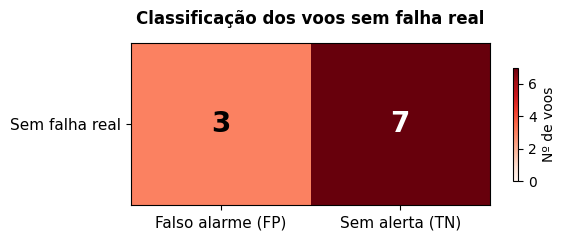

In [11]:
NO_FAULT_CATEGORIES = ["Falso alarme (FP)", "Sem alerta (TN)"]

no_fault_results = [r for r in all_results if not r["has_fault"]]
nf_counts = {cat: 0 for cat in NO_FAULT_CATEGORIES}

print(f"{'Voo':<60}  Classificação")
print("-" * 80)
for r in no_fault_results:
    cat = "Falso alarme (FP)" if r["y_pred"].any() else "Sem alerta (TN)"
    nf_counts[cat] += 1
    print(f"  {r['flight'].replace('carbonZ_', ''):<58}  {cat}")

print(f"\nTotal de voos sem falha real: {len(no_fault_results)}")
for cat in NO_FAULT_CATEGORIES:
    print(f"  {cat}: {nf_counts[cat]}")

# --- Visualização como matriz 2×1 ---
nf_data = np.array([[nf_counts[cat] for cat in NO_FAULT_CATEGORIES]])

fig, ax = plt.subplots(figsize=(6, 2.5))
vmax_nf = max(nf_data[0]) if max(nf_data[0]) > 0 else 1
im = ax.imshow(nf_data, cmap="Reds", aspect="auto", vmin=0, vmax=vmax_nf)

ax.set_xticks(range(len(NO_FAULT_CATEGORIES)))
ax.set_xticklabels(NO_FAULT_CATEGORIES, fontsize=11)
ax.set_yticks([0])
ax.set_yticklabels(["Sem falha real"], fontsize=11)

for j in range(len(NO_FAULT_CATEGORIES)):
    val = int(nf_data[0, j])
    cor = "white" if val >= vmax_nf * 0.6 else "black"
    ax.text(j, 0, str(val), ha="center", va="center", fontsize=20,
            fontweight="bold", color=cor)

ax.set_title("Classificação dos voos sem falha real",
             fontsize=12, fontweight="bold", pad=14)
plt.colorbar(im, ax=ax, shrink=0.7, label="Nº de voos")
plt.tight_layout()
plt.show()

## Métricas de Precisão, Recall e F1

Calculadas no nível de **janela** (cada amostra de `WINDOW_SIZE` passos),
separadamente para **voos com falha** e **voos sem falha**.

| Métrica | Definição |
|---------|-----------|
| **Precisão** | Dos alertas emitidos, quantos correspondem a janelas reais de falha |
| **Recall** | Das janelas de falha real, quantas foram alertadas |
| **F1** | Média harmônica entre precisão e recall |

> Nos voos sem falha `y_true = 0` em todas as janelas — a precisão da classe Normal
> é sempre 1,0; o recall mostra a fração de janelas normais classificadas corretamente
> (equivalente a `1 − taxa de falsos alarmes`).

In [12]:
from sklearn.metrics import precision_recall_fscore_support

fault_res    = [r for r in all_results if r["has_fault"]]
no_fault_res = [r for r in all_results if not r["has_fault"]]

y_true_fault   = np.concatenate([r["y_true"] for r in fault_res])
y_pred_fault   = np.concatenate([r["y_pred"] for r in fault_res])
y_true_nofault = np.concatenate([r["y_true"] for r in no_fault_res])
y_pred_nofault = np.concatenate([r["y_pred"] for r in no_fault_res])


def fmt_metrics(y_true, y_pred, labels, names):
    p, r, f, sup = precision_recall_fscore_support(
        y_true, y_pred, labels=labels, zero_division=0
    )
    rows = [
        {"Classe": name, "Precisão": pi, "Recall": ri, "F1": fi, "Suporte (janelas)": int(si)}
        for name, pi, ri, fi, si in zip(names, p, r, f, sup)
    ]
    return pd.DataFrame(rows).set_index("Classe")


print("=" * 55)
print("  Voos COM falha real")
print("=" * 55)
df_fault_metrics = fmt_metrics(
    y_true_fault, y_pred_fault,
    labels=[0, 1], names=["Normal (0)", "Falha (1)"]
)
print(df_fault_metrics.to_string(float_format=lambda x: f"{x:.4f}"))

print("\n" + "=" * 55)
print("  Voos SEM falha real")
print("=" * 55)
df_nofault_metrics = fmt_metrics(
    y_true_nofault, y_pred_nofault,
    labels=[0], names=["Normal (0)"]
)
print(df_nofault_metrics.to_string(float_format=lambda x: f"{x:.4f}"))

print("\n" + "=" * 55)
print("  Todos os voos — combinado")
print("=" * 55)
y_true_all = np.concatenate([y_true_fault, y_true_nofault])
y_pred_all = np.concatenate([y_pred_fault, y_pred_nofault])
df_all_metrics = fmt_metrics(
    y_true_all, y_pred_all,
    labels=[0, 1], names=["Normal (0)", "Falha (1)"]
)
print(df_all_metrics.to_string(float_format=lambda x: f"{x:.4f}"))

  Voos COM falha real
            Precisão  Recall     F1  Suporte (janelas)
Classe                                                
Normal (0)    0.9554  0.9926 0.9737             244190
Falha (1)     0.9548  0.7717 0.8536              49511

  Voos SEM falha real
            Precisão  Recall     F1  Suporte (janelas)
Classe                                                
Normal (0)    1.0000  0.9791 0.9894              49554

  Todos os voos — combinado
            Precisão  Recall     F1  Suporte (janelas)
Classe                                                
Normal (0)    0.9626  0.9903 0.9763             293744
Falha (1)     0.9307  0.7717 0.8438              49511
